Task 1: Load and Inspect Data

In [2]:
import pandas as pd

# Load sample data
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
df = pd.read_csv(url)

# Basic inspection
print(df.head())
print(df.info())


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


Task 2: Clean and Manipulate

In [3]:
# Convert 'sex' and 'smoker' to lowercase
df['sex'] = df['sex'].str.lower()
df['smoker'] = df['smoker'].str.lower()

# Calculate tip percentage
df['tip_pct'] = df['tip'] / df['total_bill'] * 100

# Filter rows where total_bill > 20
big_bills = df[df['total_bill'] > 20]

# Group by day and calculate average tip percentage
avg_tip_by_day = df.groupby('day')['tip_pct'].mean()
print(avg_tip_by_day)


day
Fri     16.991303
Sat     15.315172
Sun     16.689729
Thur    16.127563
Name: tip_pct, dtype: float64


Step 2: Data Visualization Practice

/var/folders/l7/n8_m5_g57sqc7hp67g48hqr40000gn/T/ipykernel_81625/2281728089.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='day', y='tip_pct', ci=None)


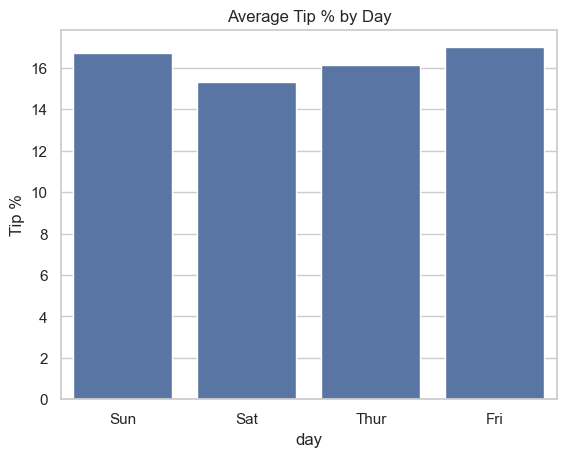

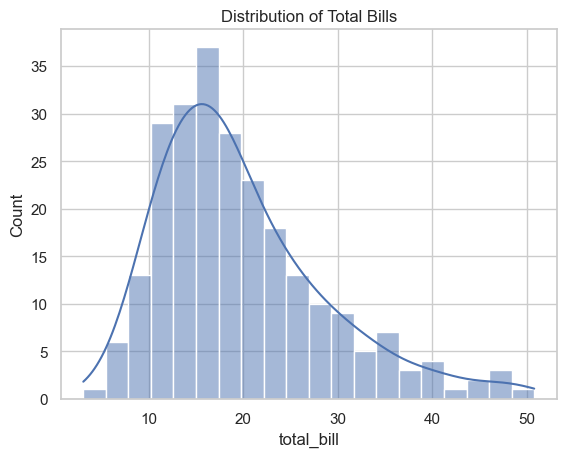

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style='whitegrid')

# Plot tip percentage by day
sns.barplot(data=df, x='day', y='tip_pct', ci=None)
plt.title("Average Tip % by Day")
plt.ylabel("Tip %")
plt.show()

# Histogram of total bills
sns.histplot(df['total_bill'], bins=20, kde=True)
plt.title("Distribution of Total Bills")
plt.show()


Step 3: Time-Series Practice

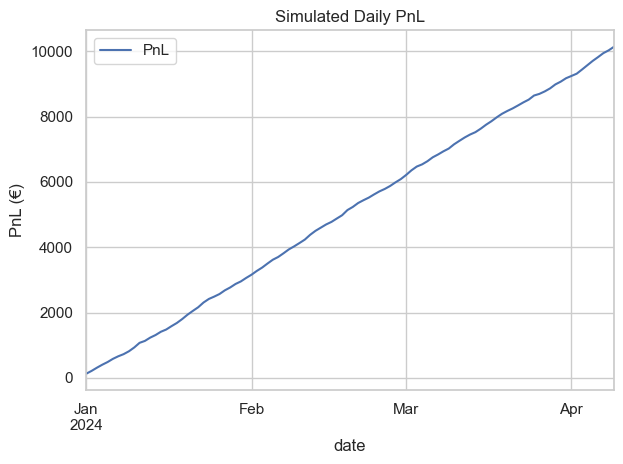

In [5]:
import numpy as np

# Generate a datetime index
dates = pd.date_range(start='2024-01-01', periods=100)

# Create fake trading PnL data
pnl = np.random.normal(loc=100, scale=20, size=100).cumsum()

# Create DataFrame
ts_df = pd.DataFrame({'date': dates, 'PnL': pnl})
ts_df.set_index('date', inplace=True)

# Plot it
ts_df.plot(title='Simulated Daily PnL')
plt.ylabel('PnL (€)')
plt.tight_layout()
plt.show()


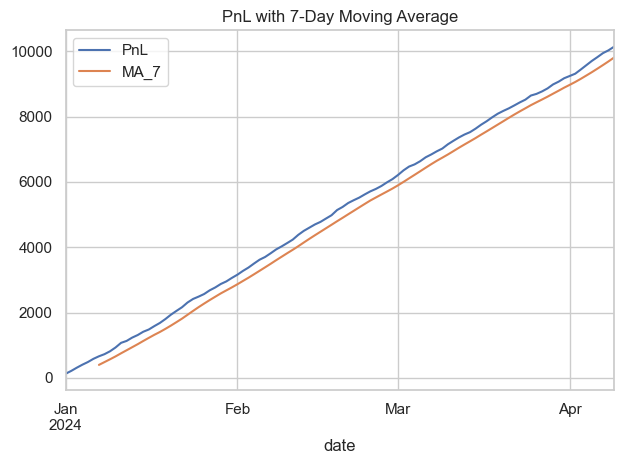

In [6]:
# Moving average (7-day)
ts_df['MA_7'] = ts_df['PnL'].rolling(window=7).mean()

# Plot with moving average
ts_df.plot(title='PnL with 7-Day Moving Average')
plt.tight_layout()
plt.show()
